# Explaining Urban Habitability through Interpretable Modeling: A Group-Based Analysis of U.S. Cities
**Student ID: 2921209P**  
31.03.2025

## 1. Introduction
Amid the continuous acceleration of global urbanization, urban habitability has become a key indicator of sustainable development and the well-being of residents. Studies have pointed out that habitability is subject to the combined effects of multidimensional factors such as the natural environment, socioeconomic conditions, and spatial structure (Zhan et al., 2018). In recent years, scholars have increasingly recognized that habitability not only depends on objective environmental quality but is also strongly influenced by subjective satisfaction, which together constitute residents' overall perception of the quality of urban life (Mouratidis, 2020).

While habitability is of universal importance, its manifestation varies across countries and regions. In the United States, a highly urbanized and socially structured country, significant intra-urban disparities exist in housing quality, transport accessibility, infrastructure distribution, and neighborhood safety (Frost et al., 2018). Systematic differences between neighborhoods further suggest that habitability cannot be comprehensively measured through a single dimension (Stanislav and Chin, 2019).

To address this complexity, we employ interpretable machine learning models within a group-based analytical framework. Using a dataset covering U.S. housing and neighborhood characteristics, cities are classified into high and low habitability groups via quantile-based thresholds. This approach not only enhances the objectivity of habitability assessment but also enables differentiated policy insights that address each group’s unique determinants.

Accordingly, this study aims to:

1. Construct interpretable models to identify key habitability drivers across city groups.
2. Propose governance strategies based on inter-group disparities in habitability drivers.

## 2. Data
### 2.1 Data Import and Overview
The dataset used in this study is from Kaggle's 2024 ‘ML Olympics - Sustainable Urban Living’ competition. It comprises 31,599 entries, each representing a residential unit in a U.S. city, and includes multidimensional variables such as property attributes, environmental conditions, infrastructure services, subjective neighborhood ratings, and a target variable, Habitability score, which represents the overall habitability score of the property on a scale from 0 to 100.

The following is the basic structure of the dataset and the first 5 rows of samples:

In [2]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import shap

In [4]:
df = pd.read_csv("/Users/stuber/Desktop/UA/train.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31599 entries, 0 to 31598
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Id                      31599 non-null  object 
 1   Property_Type           31599 non-null  object 
 2   Property_Area           31599 non-null  int64  
 3   Number_of_Windows       30266 non-null  float64
 4   Number_of_Doors         31599 non-null  int64  
 5   Furnishing              30771 non-null  object 
 6   Frequency_of_Powercuts  30490 non-null  float64
 7   Power_Backup            31599 non-null  object 
 8   Water_Supply            31599 non-null  object 
 9   Traffic_Density_Score   31599 non-null  float64
 10  Crime_Rate              30970 non-null  object 
 11  Dust_and_Noise          30600 non-null  object 
 12  Air_Quality_Index       31599 non-null  float64
 13  Neighborhood_Review     31599 non-null  float64
 14  Habitability_score      31599 non-null

In [6]:
print(" Table 1: Preview of the First Five Rows of the Dataset")
df.head()

 Table 1: Preview of the First Five Rows of the Dataset


,Id,Property_Type,Property_Area,Number_of_Windows,Number_of_Doors,Furnishing,Frequency_of_Powercuts,Power_Backup,Water_Supply,Traffic_Density_Score,Crime_Rate,Dust_and_Noise,Air_Quality_Index,Neighborhood_Review,Habitability_score
0,0x21e3,Apartment,106,NaN,1,Semi_Furnished,0.0,No,Once in a day - Morning,5.89,Slightly below average,Medium,90.0,3.86,71.98
1,0x68d4,Apartment,733,2.0,2,Unfurnished,1.0,No,Once in a day - Evening,4.37,Well below average,Medium,96.0,3.55,71.20
2,0x7d81,Apartment,737,4.0,2,Fully Furnished,0.0,No,Once in a day - Morning,7.45,Slightly below average,Medium,121.0,3.81,71.39
3,0x7a57,Apartment,900,3.0,2,Unfurnished,2.0,Yes,Once in a day - Morning,6.16,Well above average,Medium,100.0,1.34,31.46
4,0x9409,Bungalow,2238,14.0,6,Fully Furnished,0.0,No,All time,5.46,Well below average,Medium,116.0,4.77,93.70


### 2.2 Data Cleaning and Encoding
To ensure data quality and adapt to the subsequent modeling, we first systematically cleaned the original dataset and encoded it. Preliminary inspection showed that a small percentage of variables were missing, mainly focusing on Number_of_Windows (4.2%), Frequency_of_Powercuts (3.5%), Dust_and_Noise (3.2%), Furnishing (2.6%), and Crime_Rate (2.0%). ). These missing percentages are all less than 5%, which is within the acceptable range and has a limited impact on the representativeness of the sample.

In [9]:
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100
missing_summary = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Missing_Percent': missing_percent.round(2)
})
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]
missing_summary = missing_summary.sort_values(by='Missing_Percent', ascending=False)

print("Table 2: Columns with missing values")
missing_summary

Table 2: Columns with missing values


,Missing_Count,Missing_Percent
Number_of_Windows,1333,4.22
Frequency_of_Powercuts,1109,3.51
Dust_and_Noise,999,3.16
Furnishing,828,2.62
Crime_Rate,629,1.99


The data-cleaning process comprises the following three steps:
1. Duplicate Removal: All duplicate records were removed to avoid potential bias arising from repeated observations during model training.
2. Missing Value Imputation: For numerical variables, missing values were estimated using the median to mitigate the effect of extreme values. For categorical variables, the mode number was used to retain the main category structure.
3. Categorical Encoding: All variables of type object were converted into integer format using LabelEncoder to ensure compatibility with regression models that require numerical inputs.


In [11]:
def clean_data(df):
    """
    Cleans the input DataFrame:
    - Removes duplicates;
    - Fills missing values (median for numerical, mode for categorical);
    - Encodes object-type categorical variables using LabelEncoder;
    - Applies reverse coding to selected ordinal variables.
    Returns a cleaned DataFrame.
    """
    df = df.drop_duplicates()
    
    for col in df.columns:
        if df[col].dtype in [np.float64, np.int64]:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

    obj_cols = df.select_dtypes(include='object').columns
    for col in obj_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])

    reverse_cols = [
        'Furnishing',
        'Frequency_of_Powercuts',
        'Water_Supply',
        'Traffic_Density_Score',
        'Crime_Rate',
        'Dust_and_Noise'
    ]
    for col in reverse_cols:
        if col in df.columns:
            df[col] = df[col].max() + 1 - df[col]

    return df

df_clean = clean_data(df)
print("Data cleaned and encoded.")

Data cleaned and encoded.


## 3. Exploratory Data Analysis and Grouping Strategy
### 3.1 Distribution of Habitability Score
Before the modeling, we conducted a distributional analysis of the target variable habitability_score. A combination of histogram and kernel density estimation (KDE) plots was used to visualize its overall distributional characteristics, including skewness, kurtosis, and structural patterns.

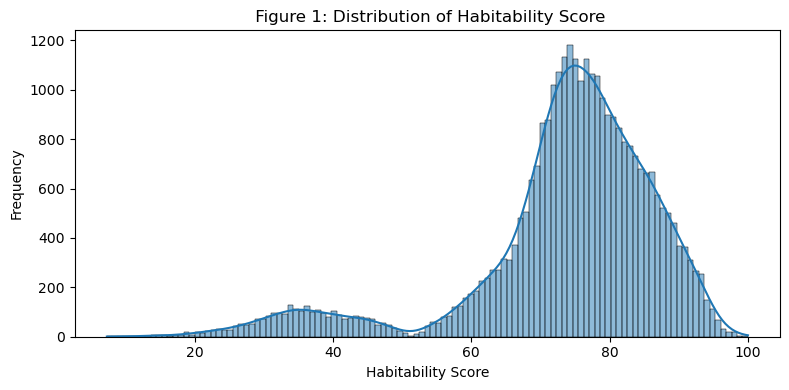

In [13]:
plt.figure(figsize=(8, 4))
sns.histplot(df_clean['Habitability_score'], kde=True)
plt.title(" Figure 1: Distribution of Habitability Score")
plt.xlabel("Habitability Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

As shown in Figure 1, the distribution of habitability scores is right-skewed, with two distinct peaks at scores of approximately 35 and 75, respectively. This suggests a clear bimodal distribution and may hint at a potential stratification of city habitability levels, i.e., the dataset may consist of two groups of cities with different characteristics.

To further investigate the heterogeneity of variable impacts, we will use the median as a threshold to categorize cities into two groups: high and low habitability cities. Although the distribution of the habitability scores is right skewed and the peak of the high score segment dominates, using the median allows for a relatively balanced division of the dataset. This ensures that both groups have sufficient sample sizes for comparative modeling while maintaining robustness to skewness and outliers.

### 3.2 Preliminary Variable Selection
Based on our understanding of the distribution of the target variables, we further explored the relationship between the variables and the habitability scores. A systematic traversal of the variable types was undertaken and targeted visual analyses were carried out to inform subsequent feature selection for modeling.

These features can be categorized into two groups:

1. Continuous variables: Scatter plots were employed to examine potential linear or non-linear associations with the habitability_score.
2. Categorical variables: Box plots were used to visualize the distribution of scores across different categories, enabling assessment of inter-group differences.

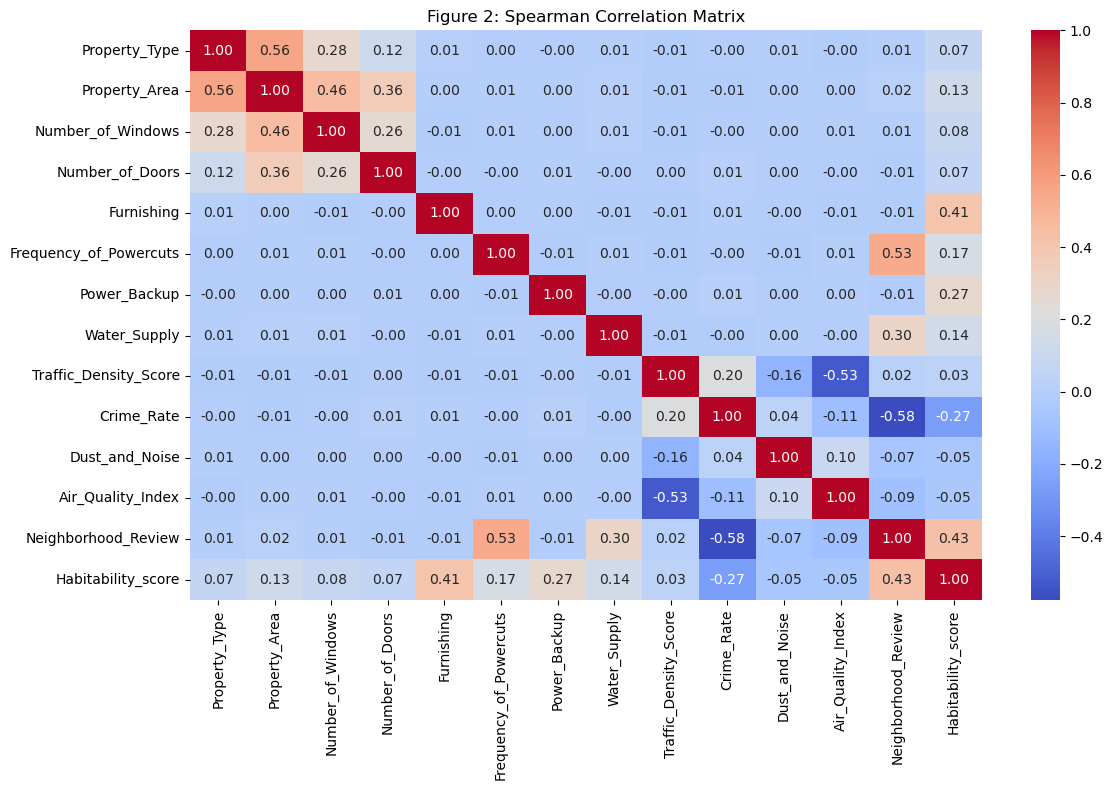

In [15]:
plt.figure(figsize=(12, 8))
corr = df_clean.drop(columns=["Id"]).corr(method='spearman')
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Figure 2: Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

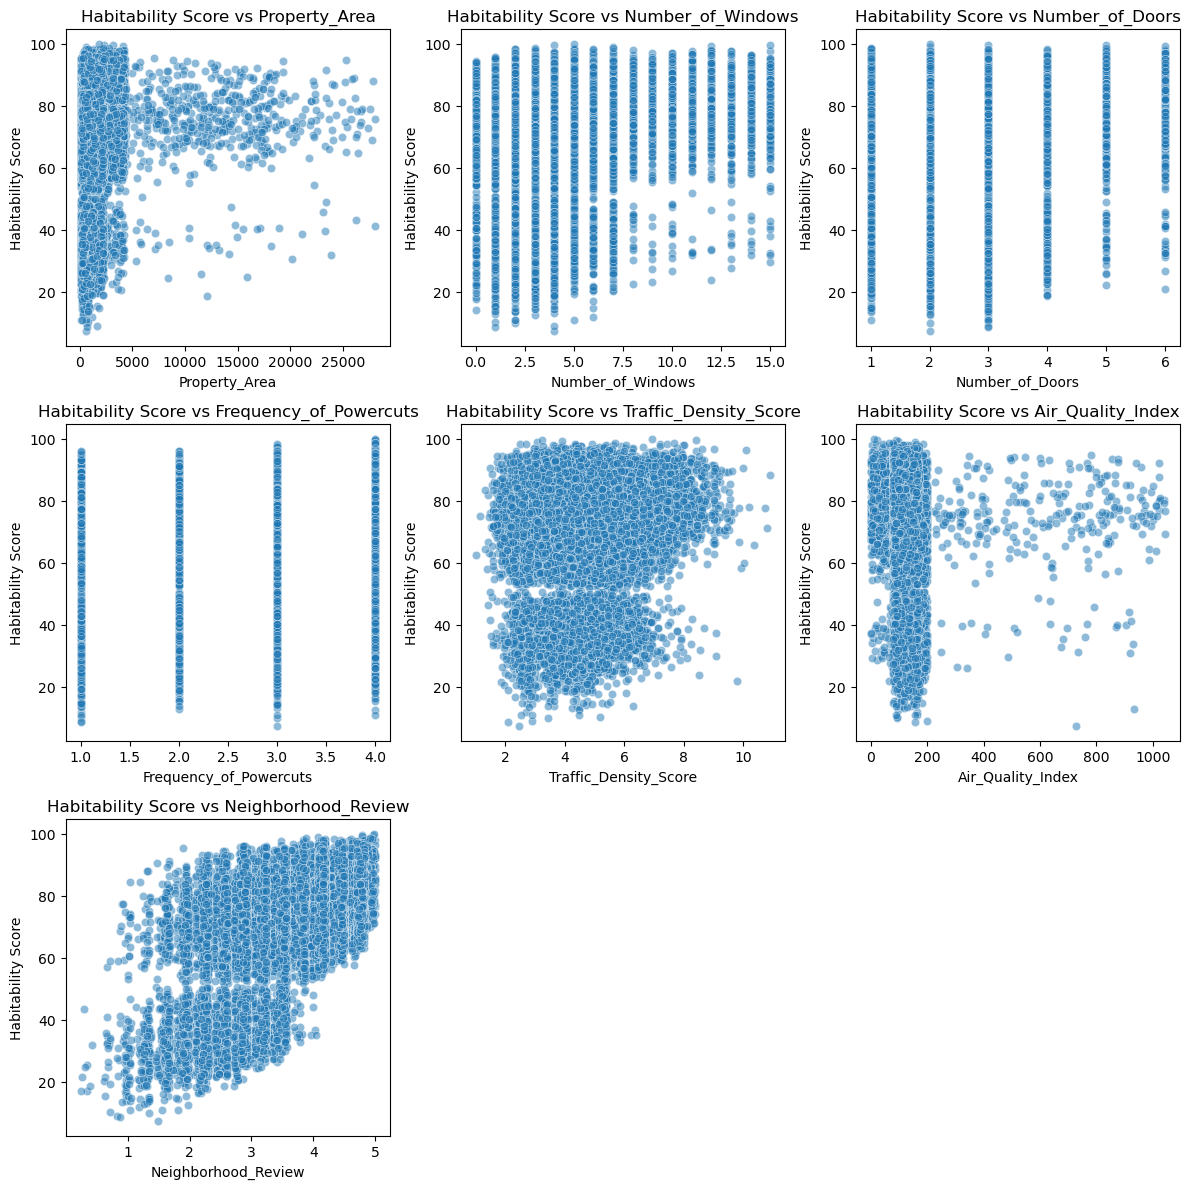

In [17]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
numerical_cols = numerical_cols.drop(['Habitability_score', 'Id'], errors='ignore')

n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.scatterplot(data=df_clean, x=col, y='Habitability_score', alpha=0.5, ax=axes[i])
    axes[i].set_title(f'Habitability Score vs {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Habitability Score')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

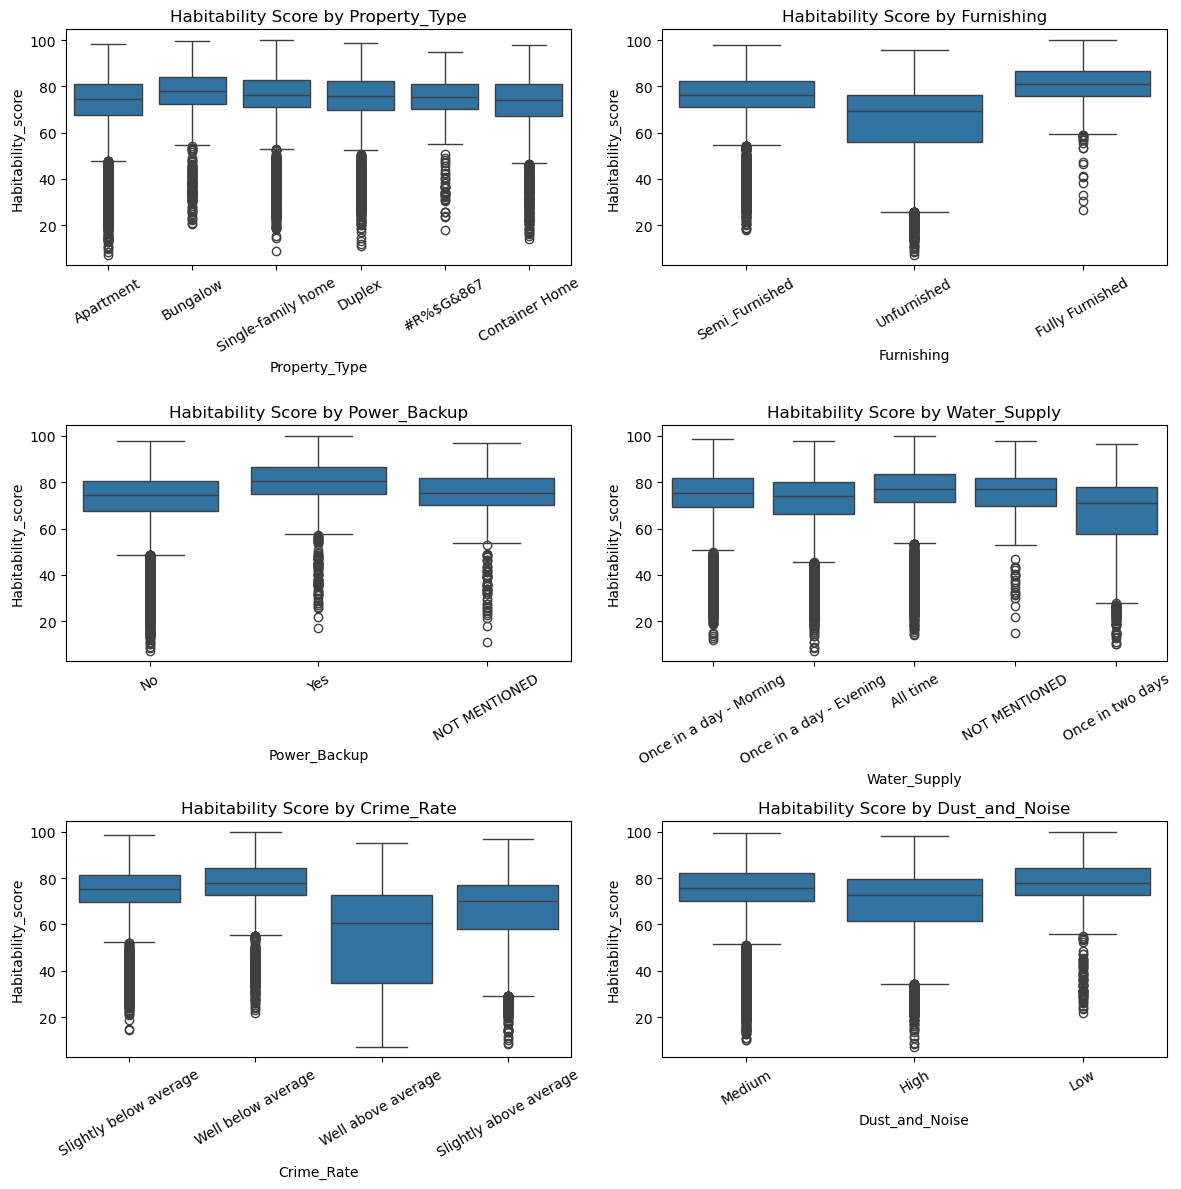

In [19]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ['Habitability_score', 'Id']]

n_cols = 2
n_rows = math.ceil(len(categorical_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.boxplot(data=df, x=col, y='Habitability_score', ax=axes[i])
    axes[i].set_title(f'Habitability Score by {col}')
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

As shown in the analysis above, The Spearman correlation matrix reveals several statistically meaningful relationships between habitability_score and key predictors. Neighborhood_review (ρ = 0.43) and furnishing (ρ = 0.41) exhibit moderate positive correlations, highlighting the importance of residents' subjective evaluations of neighborhood and the level of interior furnishing in shaping perceived habitability. Additionally, power_backup (ρ = 0.27) and frequency_of_powercuts (ρ = 0.17) show positive associations, indicating that infrastructure stability contributes to better residential experience. On the other hand, crime_rate (ρ = -0.27) and traffic_density_score (ρ = -0.14) are negatively correlated with habitability, suggesting that safety concerns and traffic congestion serve as limiting factors. It is worth noting that the air_quality_index shows a weak negative correlation (ρ = -0.05), which aligns with theoretical expectations but may be weakened by variations in pollution levels across cities.

The scatterplots and boxplots provide clear visual evidence of how various features relate to habitability_score. Among continuous variables, both property_area and number_of_windows display upward trends, suggesting that larger homes and better ventilation conditions may enhance habitability. Neighborhood_review shows the most distinct linear gradient, reinforcing the strong role of subjective satisfaction in perceived habitability. In contrast, the relationship between air_quality_index and habitability appears weaker, though a general pattern of cleaner air aligning with higher satisfaction can still be observed in the low-pollution range. For categorical variables, there are substantial differences in score distributions across levels of furnishing, power_backup, and water_supply, all of which reflect the importance of infrastructure adequacy. For example, properties that are fully furnished or have all-time water supply exhibit notably higher median habitability scores.

Accordingly, ten key features were selected for modeling: 

1.	Housing structure: Property_Area, Furnishing, Number_of_Windows
2.	Infrastructure: Power_Backup, Frequency_of_Powercuts, Water_Supply
3.	Environment and neighborhood: Crime_Rate, Dust_and_Noise, Air_Quality_Index, Neighborhood_Review

### 3.3 Kruskal-Wallis Analysis

In [21]:
categorical_vars = ['Furnishing', 'Power_Backup', 'Water_Supply', 'Crime_Rate', 'Dust_and_Noise']

kruskal_results = []
for var in categorical_vars:
    groups = [df_clean[df_clean[var] == level]['Habitability_score'].dropna() for level in df_clean[var].unique()]
    statistic, pvalue = kruskal(*groups)
    kruskal_results.append({
        'Variable': var,
        'H-statistic': round(statistic, 2),
        'p-value': pvalue
    })

kruskal_df = pd.DataFrame(kruskal_results)
kruskal_df['Significant'] = kruskal_df['p-value'].apply(lambda x: '***' if x < 0.001 else ('**' if x < 0.01 else ('*' if x < 0.05 else 'ns')))

print(kruskal_df)

         Variable  H-statistic        p-value Significant
0      Furnishing      5439.88   0.000000e+00         ***
1    Power_Backup      2617.84   0.000000e+00         ***
2    Water_Supply      1058.20  8.689916e-228         ***
3      Crime_Rate      4155.57   0.000000e+00         ***
4  Dust_and_Noise       417.01   2.803303e-91         ***


Since the target variable showed a distinctly non-normal bimodal distribution, it does not meet the assumptions of the ANOVA. Therefore, we chose the non-parametric Kruskal-Wallis test, which is less restrictive on distribution, to examine the differences in habitability scores for the main categorical variables. The results showed significant differences (p<0.001) between all categorical variables, thus confirming their importance in subsequent modelling. In contrast, continuous variables were excluded from this test as they are more appropriately explored through correlation analyses and regression methods, as discussed earlier in section 3.2.

### 3.4 City Grouping by Quantile Threshold
Given the observed bimodal distribution of the target variable habitability scores, we used a quantile-based approach to divide the city sample into two groups: high and low habitability cities. Specifically, we use the median as the threshold to classify the data into group 0 (low habitability cities) and group 1 (high habitability cities).

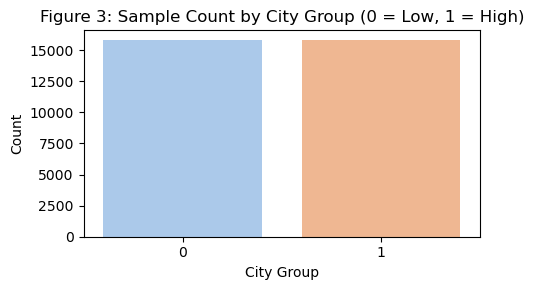

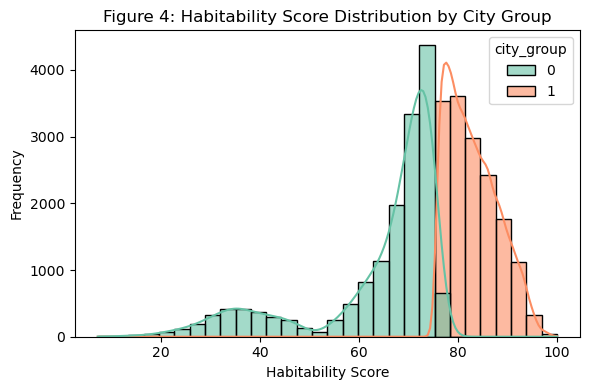

In [23]:
def generate_group(df):
    """
    Split cities into high- and low-habitability groups based on the median.
    Group 0: Habitability_score < median
    Group 1: Habitability_score >= median
    """
    df = df.copy()
    threshold = df['Habitability_score'].median()
    df['city_group'] = (df['Habitability_score'] >= threshold).astype(int)
    return df

df_grouped = generate_group(df_clean)

plt.figure(figsize=(5, 3))
sns.countplot(data=df_grouped, x='city_group', hue='city_group', palette='pastel', legend=False)
plt.title("Figure 3: Sample Count by City Group (0 = Low, 1 = High)")
plt.xlabel("City Group")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.histplot(data=df_grouped, x='Habitability_score', hue='city_group',
             kde=True, bins=30, palette='Set2', alpha=0.6)
plt.title("Figure 4: Habitability Score Distribution by City Group")
plt.xlabel("Habitability Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

The figures show that the two habitability groups by the median, the high habitability group (Group 1) and the low habitability group (Group 0), are balanced in terms of sample size. The distribution of scores further shows that Group 0 is mainly concentrated below 60 points, with a relatively dispersed distribution and a distinct right tail. In contrast, Group 1 scores are more tightly distributed, mainly between 70 and 90 points. This pattern is consistent with the bimodal structure observed in the original target variable, showing that median-based segmentation effectively captures the potential stratification of habitability levels and provides a good basis for group modeling.

## 4. Feature Engineering and Preprocessing
### 4.1 Feature Selection
Based on the preceding analysis, the following variables have been selected as core features, with the residents' rating of habitability_score serving as the target variable. These features demonstrate either statistical correlations with the target variable or significant differences between groups and thus possess strong interpretability for subsequent modeling.

In [25]:
df_clean = clean_data(df)

variable_info = pd.DataFrame({
    'Variable': [
        'Property_Area', 'Furnishing', 'Number_of_Windows',
        'Power_Backup', 'Water_Supply', 'Frequency_of_Powercuts',
        'Air_Quality_Index', 'Crime_Rate', 'Dust_and_Noise', 'Neighborhood_Review',
        'Habitability_score'
    ],
    'Dimension': [
        'Physical Attributes', 'Physical Attributes', 'Physical Attributes',
        'Infrastructure Access', 'Infrastructure Access', 'Infrastructure Access',
        'Environmental Quality', 'Environmental Quality', 'Environmental Quality', 'Subjective Satisfaction',
        'Target Variable'
    ],
    'Description': [
        'Total property area',
        'Furnishing status of the house',
        'Number of windows in the house',
        'Availability of power backup',
        'Water supply frequency',
        'Frequency of electricity power cuts',
        'Air pollution index',
        'Neighborhood safety level',
        'Level of dust and noise pollution',
        'Residents’ review of neighborhood',
        'Overall habitability score of the property'
    ]
})

print("Table 3: Key variable classification table")
display(variable_info)

Table 3: Key variable classification table


,Variable,Dimension,Description
0,Property_Area,Physical Attributes,Total property area
1,Furnishing,Physical Attributes,Furnishing status of the house
2,Number_of_Windows,Physical Attributes,Number of windows in the house
3,Power_Backup,Infrastructure Access,Availability of power backup
4,Water_Supply,Infrastructure Access,Water supply frequency
5,Frequency_of_Powercuts,Infrastructure Access,Frequency of electricity power cuts
6,Air_Quality_Index,Environmental Quality,Air pollution index
7,Crime_Rate,Environmental Quality,Neighborhood safety level
8,Dust_and_Noise,Environmental Quality,Level of dust and noise pollution
9,Neighborhood_Review,Subjective Satisfaction,Residents’ review of neighborhood


### 4.2 Outlier Handling
Outlier detection and treatment are necessary to reduce the impact of extreme values on model training and prediction. In this study, the interquartile range (IQR) method is used to clip the upper and lower bounds of selected numerical variables. This method calculates the median and interquartile range of each variable. It clips the outliers to a statistically reasonable range, which does not remove any original observations but effectively mitigates the instability caused by the outliers.

In [27]:
def clip_outliers(df, col):
    """
    Apply IQR-based clipping to remove outliers in the specified column.
    """
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)
    return df

numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
numeric_cols = numeric_cols.drop(['Id'], errors='ignore') 

for col in numeric_cols:
    df_clean = clip_outliers(df_clean, col)

print("Outlier clipping completed.")

Outlier clipping completed.


### 4.3 RobustScaler and Train-Test Split
To reduce the influence of extreme values on model training and to unify variable scales, all selected continuous variables are standardized using RobustScaler. This method is particularly robust to non-normal distributions and outliers, helping to enhance the stability and generalizability of the model. Subsequently, to support the group modelling strategy, the dataset is split into two subsets based on the city group (high and low habitability). Separate models will be trained for each subgroup in subsequent steps.

In [29]:
selected_features = [
    'Property_Area', 'Number_of_Windows',
    'Power_Backup', 'Water_Supply', 'Furnishing', 'Frequency_of_Powercuts',
    'Air_Quality_Index', 'Crime_Rate', 'Dust_and_Noise', 'Neighborhood_Review'
]

scaler = RobustScaler()

X_scaled = scaler.fit_transform(df_grouped[selected_features])

X_scaled_df = pd.DataFrame(X_scaled, columns=selected_features)
X_scaled_df['Habitability_score'] = df_grouped['Habitability_score']
X_scaled_df['city_group'] = df_grouped['city_group']

In [31]:
df_low = X_scaled_df[X_scaled_df['city_group'] == 0]
df_high = X_scaled_df[X_scaled_df['city_group'] == 1]

## 5. Modeling and Evaluation
To systematically evaluate the explanatory power of different features on urban habitability, we employ the Random Forest Regressor to build predictive models. Three modeling scenarios are designed as follows:

1. Model A (All Model): Trained and tested on the entire dataset to capture overall influence patterns.
2. Model B (Low Habitability Model): Built exclusively on Group 0 samples to uncover factors specific to low habitability cities.
3. Model C (High Habitability Model): Focused on Group 1 samples to identify key drivers of habitability improvement in high-performing cities.

All models use the same feature set and follow an 80% / 20% split between training and testing sets to ensure fairness and comparability. Model performance is evaluated using two key metrics: R² (coefficient of determination) and MSE (mean squared error).

In [33]:
X_all = X_scaled_df[selected_features]
y_all = X_scaled_df['Habitability_score']
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

X_low = df_low[selected_features]
y_low = df_low['Habitability_score']
X_train_low, X_test_low, y_train_low, y_test_low = train_test_split(X_low, y_low, test_size=0.2, random_state=42)

X_high = df_high[selected_features]
y_high = df_high['Habitability_score']
X_train_high, X_test_high, y_train_high, y_test_high = train_test_split(X_high, y_high, test_size=0.2, random_state=42)

### 5.1 Model Training and Preliminary Results

In [35]:
def train_and_evaluate(X_train, y_train, X_test, y_test, model_name='Model'):
    model = RandomForestRegressor(random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    print(f"[{model_name}] R² = {r2:.3f}, MSE = {mse:.2f}")
    return model, y_pred, r2, mse

In [37]:
model_all, y_pred_all, r2_all, mse_all = train_and_evaluate(
    X_train_all, y_train_all, X_test_all, y_test_all, model_name='Model A (All)'
)

model_low, y_pred_low, r2_low, mse_low = train_and_evaluate(
    X_train_low, y_train_low, X_test_low, y_test_low, model_name='Model B (Low Habitability)'
)

model_high, y_pred_high, r2_high, mse_high = train_and_evaluate(
    X_train_high, y_train_high, X_test_high, y_test_high, model_name='Model C (High Habitability)'
)

[Model A (All)] R² = 0.808, MSE = 36.46
[Model B (Low Habitability)] R² = 0.833, MSE = 31.93
[Model C (High Habitability)] R² = 0.383, MSE = 15.77


Under a consistent feature set and training setup, the three models exhibit significant differences in performance. Model B (low habitability city group) has the highest explanatory power with an R² of 0.833, indicating that habitability scores in low-performing cities are more effectively predicted by structural variables. Model C (high habitability city group) has a significantly lower R² of 0.383 despite having the lowest MSE (15.77), suggesting that structural variables have limited explanatory power in high-habitability contexts. Overall, the overall performance of Model A performs moderately(R² = 0.808) but hides heterogeneity between city groups.

### 5.2 Evaluation Metrics and Interpretation
To visualize the performance differences under different modeling strategies, we compare the prediction results of the three models on a test set.

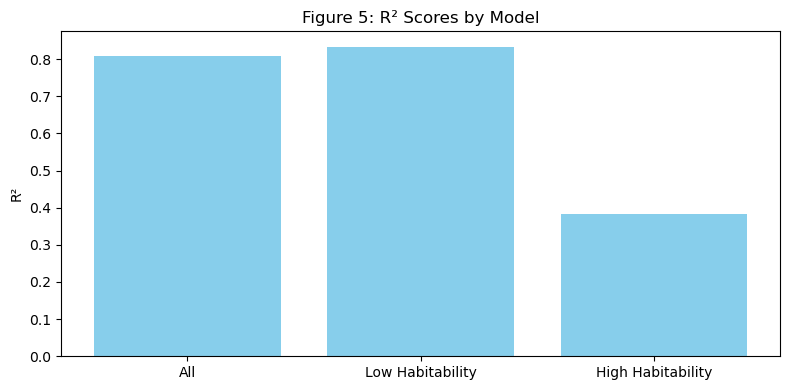

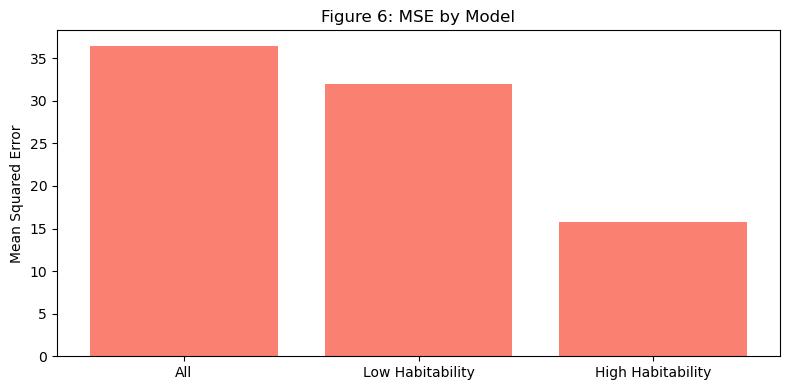

In [39]:
labels = ['All', 'Low Habitability', 'High Habitability']
r2_scores = [r2_all, r2_low, r2_high]
mse_scores = [mse_all, mse_low, mse_high]

plt.figure(figsize=(8,4))
plt.bar(labels, r2_scores, color='skyblue')
plt.title("Figure 5: R² Scores by Model")
plt.ylabel("R²")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.bar(labels, mse_scores, color='salmon')
plt.title("Figure 6: MSE by Model")
plt.ylabel("Mean Squared Error")
plt.tight_layout()
plt.show()

Figures 5 and 6 further present the R² and MSE performance of each model on the test set in a visual format. As shown in Figure 5, the low habitability group model demonstrates the highest goodness-of-fit (R²), while the R² of the high habitability group model is significantly lower. Figure 6 reveals that although the high habitability model has limited explanatory power, it achieves the lowest mean squared error (MSE), indicating that its predicted values are numerically closer to the actual scores, but show limited variability to adequately reflect the distributional diversity of the target variables.

These results reveal a structural asymmetry in how habitability is determined across urban contexts. In cities with lower habitability, perceived habitability is more strongly correlated with observable and measurable structural factors such as infrastructure reliability, environmental quality, and neighborhood safety. These cities often exhibit greater inter-unit variance in these dimensions, providing sufficient heterogeneity for the model to learn meaningful patterns. This finding aligns with Zhan et al. (2018), who emphasize the foundational role of built environment and public services in shaping baseline habitability. Conversely, in high habitability cities, these basic urban conditions tend to converge at relatively high levels, an effect often described as “saturation” in habitability research. Once fundamental needs are met, further improvements in infrastructure or space do not linearly translate into higher satisfaction. This leads to reduced explanatory power of traditional structural indicators. Instead, subjective dimensions such as perceived well-being, social cohesion, cultural identity, and emotional attachment to place—become increasingly important. These soft factors, however, are not captured in the current dataset. Moreover, all model (Model A), though achieving a decent R², tends to replicate the behavioral structure of low habitability cities, thus potentially masking the subtle dynamics of high-performing urban environments.

## 6. Feature Importance and Interpretation
To enhance the transparency and interpretability of urban habitability assessments, two mainstream approaches are employed to analyze feature importance:

1. Model-based method: Embedded feature ranking based on the Random Forest algorithm.
2. Model-agnostic method: SHAP values are used to evaluate the marginal contribution of each variable to the model's predictions.

Feature importance will be examined separately for the all model (Model A) and the two group-specific models (Model B and C), to compare the key influencing factors across different urban contexts.

### 6.1 Random Forest Importance

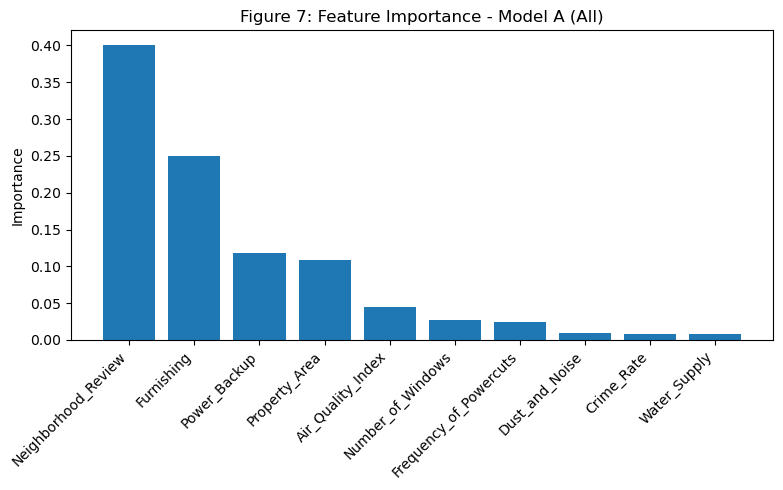

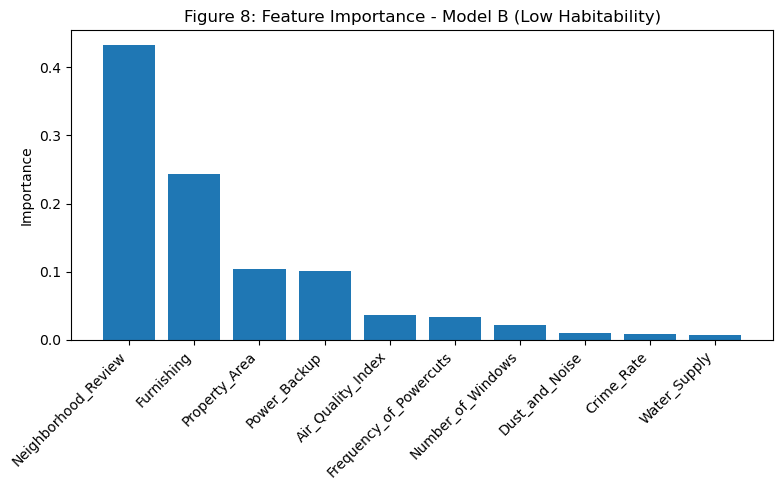

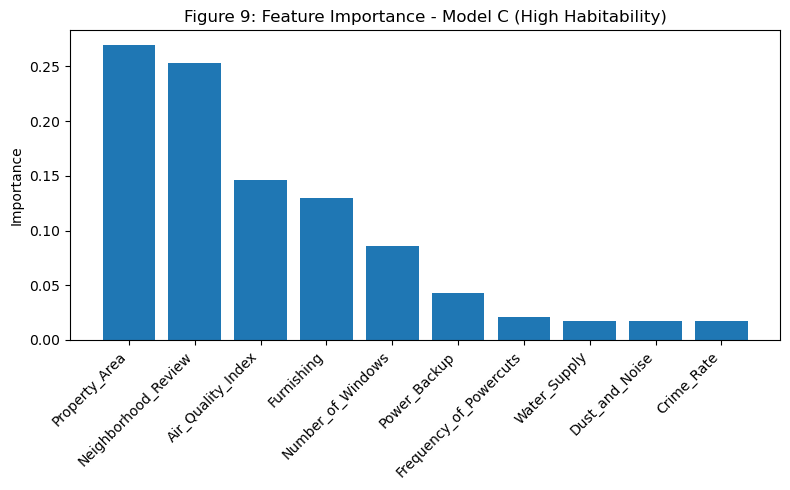

In [41]:
def plot_feature_importance(model, features, title):
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]

    plt.figure(figsize=(8,5))
    plt.bar(range(len(importances)), importances[indices], align='center')
    plt.xticks(range(len(importances)), [features[i] for i in indices], rotation=45, ha='right')
    plt.title(title)
    plt.ylabel("Importance")
    plt.tight_layout()
    plt.show()

plot_feature_importance(model_all, selected_features, "Figure 7: Feature Importance - Model A (All)")
plot_feature_importance(model_low, selected_features, "Figure 8: Feature Importance - Model B (Low Habitability)")
plot_feature_importance(model_high, selected_features, "Figure 9: Feature Importance - Model C (High Habitability)")

A careful review of the feature importance plots (Figures 7–9) reveals more than just the relative ranking of variables, it also reflects how different model structures emerge under varying urban conditions. In the low habitability model (Figure 8), Neighborhood_Review dominates the importance ranking, accounting for over 40%, while the next features like Furnishing and Property_Area contribute far less. This sharp drop suggests that one feature plays a disproportionately large role in shaping the model’s predictions.

By contrast, the high habitability model (Figure 9) presents a more even distribution: Property_Area, Neighborhood_Review, and Air_Quality_Index each contribute between 15–25%, with no single feature standing out. This flatter shape is consistent with the lower R² observed for this model and indicates that prediction variance is harder to explain in high performing cities.

These visual differences point to a key insight: feature importance is not fixed but depends on context. A feature like Property_Area may represent basic housing adequacy in low-scoring cities, but in high-scoring ones, it could be more related to comfort, spatial quality, or social status. Similarly, Neighborhood_Review is highly informative in cities with large variations in satisfaction levels but loses predictive power when those scores converge. Thus, the same variable manifests different “urban realities” under divergent structural conditions.

### 6.2 SHAP Interpretation

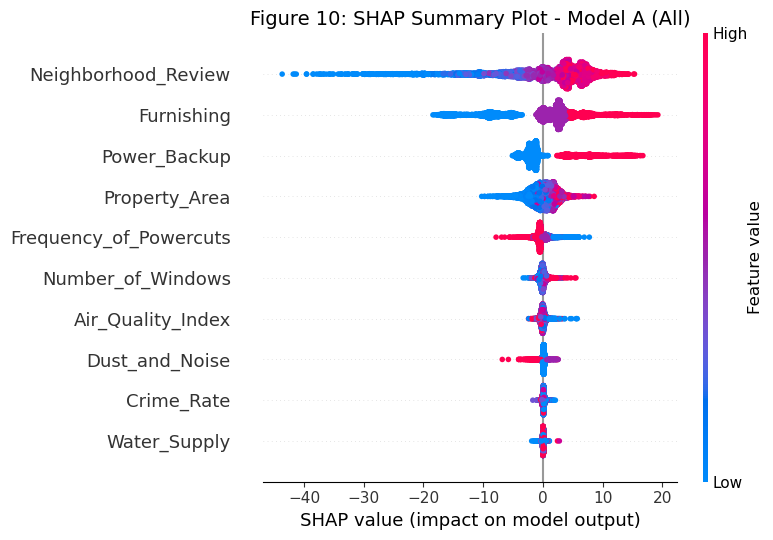

In [61]:
explainer_all = shap.TreeExplainer(model_all)
shap_values_all = explainer_all.shap_values(X_test_all)

shap.summary_plot(shap_values_all, X_test_all, feature_names=selected_features, show=False)
plt.title("Figure 10: SHAP Summary Plot - Model A (All)", fontsize=14)
plt.tight_layout()
plt.show()

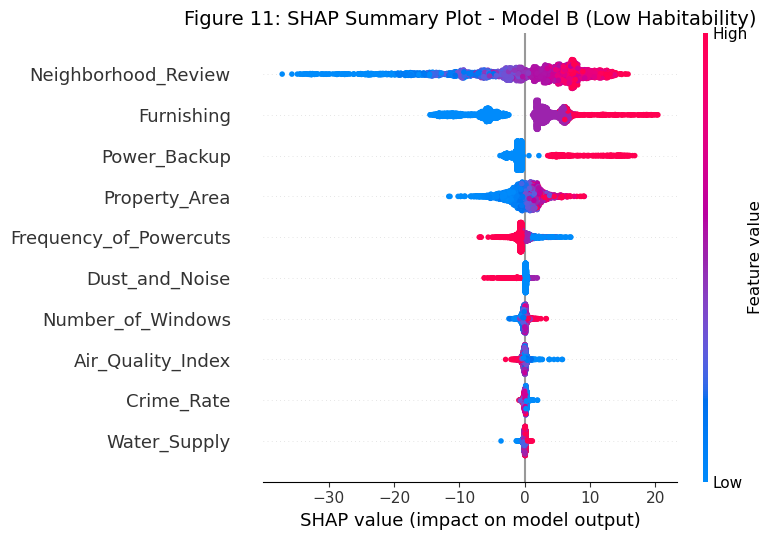

In [62]:
explainer_low = shap.TreeExplainer(model_low)
shap_values_low = explainer_low.shap_values(X_test_low)

shap.summary_plot(shap_values_low, X_test_low, feature_names=selected_features, show=False)
plt.title("Figure 11: SHAP Summary Plot - Model B (Low Habitability)", fontsize=14)
plt.tight_layout()
plt.show()

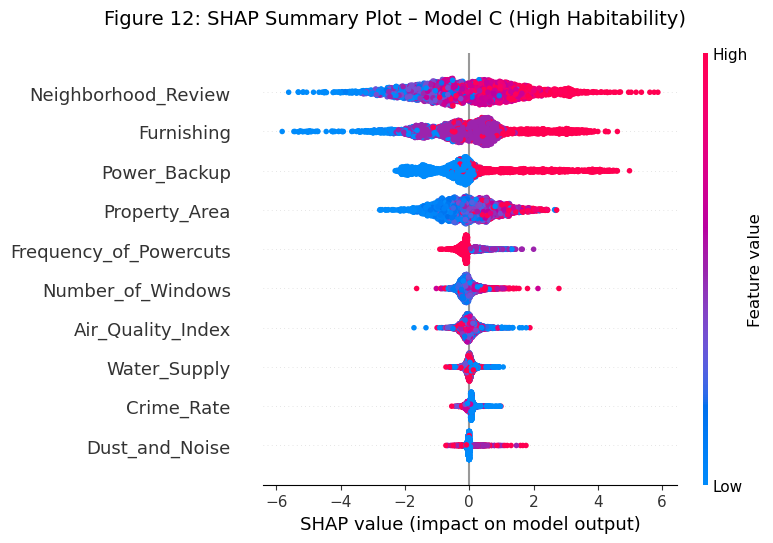

In [63]:
explainer_high = shap.TreeExplainer(model_high)
shap_values_high = explainer_high.shap_values(X_test_high)

shap.summary_plot(shap_values_high, X_test_high, feature_names=selected_features, show=False)
plt.gcf().suptitle("Figure 12: SHAP Summary Plot – Model C (High Habitability)", fontsize=14)
plt.tight_layout()
plt.show()

Compared to the bar plots in section 6.1, the SHAP summary plots (Figures 10–12) provide a more detailed understanding of how each feature affects the model’s prediction—not only showing which features are important, but also revealing the direction and strength of their influence across different values and samples.

In the all model (Figure 10), Neighborhood_Review and Furnishing remain the most influential features, similar to the results in section 6.1. However, SHAP further reveals the direction of influence of feature values: high Neighborhood_Review values (in red) consistently increase habitability scores, while low values (in blue) reduce them significantly. Property_Area, on the other hand, showsa more dispersed distribution of SHAP values, with both positive and negative effects, suggesting it has a more variable effect depending on the context.

In the group-specific models, this difference becomes clearer. In the low habitability group (Figure 11), the SHAP values of key features are more spread out, which means even small changes in Neighborhood_Review or Furnishing can have a large impact. In contrast, the high habitability group (Figure 12) shows much narrower SHAP ranges, most features only have limited influence on the predictions. This supports the earlier observation in section 6.1 that the model performs worse (lower R²) in high habitability areas.

### 6.3 Cross-Model Comparison
Comparing the outputs of all three models side-by-side reveals how the same feature set produces different patterns under distinct habitability contexts. 

In the low habitability group model (Model B), we observe a highly concentrated structure. In Figure 8, Neighborhood_Review alone dominates the feature importance chart, with over 40% weight. This is echoed in Figure 11, where the SHAP distribution of Neighborhood_Review shows wide variation. This indicates that a small number of features drive most of the model’s learning, and their effects are both strong and variable. This concentrated structure likely contributes to the model’s high R² (0.833).

By contrast, the high habitability group model (Model C) displays a more distributed pattern. As shown in Figure 9, the importance scores of the top features such as Property_Area, Neighborhood_Review, and Air_Quality_Index, are more evenly spread, each below 30%. In Figure 12, their SHAP value ranges are also narrow and centered around zero. This suggests that no single variable exerts a strong influence, and predictions are made with subtle, overlapping contributions. Combined with the low R² (0.383), this supports the hypothesis of structural convergence in high-performing cities: once basic needs are met, measurable differences no longer explain score variation as effectively.

The all model (Model A), though trained on the full sample, aligns more closely with the structure of Model B. As seen in Figure 7, its top variables and relative weights resemble those in low-scoring cities. Likewise, Figure 10 shows extended SHAP ranges for Neighborhood_Review, Furnishing, and Power_Backup. This suggests that the all model is disproportionately influenced by cities with higher variance, leading to good overall fit but weaker generalization to homogeneous high-performing areas.


## 7. Discussion and Conclusion
This study explored how interpretable machine learning models can be used to analyze urban habitability across different types of U.S. cities. Using a dataset from the Kaggle “ML Olympics – Sustainable Urban Living” competition, the project combined statistical analysis, data preprocessing, and Random Forest regression to model habitability scores. A quantile-based classification splits the cities into high and low habitability groups, enabling group-specific modeling and comparison. Feature importance rankings and SHAP analysis were employed to enhance interpretability and extract policy-relevant insights.

The results reveal clear differences in how habitability is shaped across city groups. In low habitability cities, the model relies heavily on a small number of structural and subjective features, particularly Neighborhood_Review and Furnishing, which display strong predictive power. In high habitability cities, these variables show weaker effects, and the model struggles to explain score variation, suggesting a convergence in structural conditions. The all model performs well overall but tends to reflect the patterns of low performing cities, overlooking the more nuanced dynamics present in high-performing ones.

This study also answered the central question originally posed: how to identify the drivers of habitability in different urban contexts and develop differentiated governance strategies accordingly. In low habitability cities, improvements in infrastructure, housing quality, and basic services are likely to bring clear benefits. In high-performing cities, habitability is less tied to physical conditions and more influenced by intangible or experiential factors. Therefore, policy strategies should be differentiated—focusing on service provision in poorly resourced areas, and community, identity, and quality of life in more developed ones.

Despite its contributions, this study has limitations. The Random Forest model struggles to balance structural variance between groups and explain subtle differences within them, especially in high-performing cities. The dataset also lacks soft variables such as perception, emotion, or cultural attachment, which likely shape habitability beyond infrastructure. Moreover, the binary grouping method simplifies the complex spectrum of urban conditions. Future research could address these issues by incorporating subjective or unstructured data, applying hierarchical or semantic-aware models, and exploring spatial or temporal dynamics to better capture real-world urban complexity.

#### Word count: 3258

## 8. References
Frost, A.R., Appleyard, B., Gibbons, J. and Ryan, S. 2018. Quantifying the sustainability, livability, and equity performance of urban and suburban places in California. Transportation Research Record. 2672(3), pp.130–144.

Mouratidis, K. 2020. Commute satisfaction, neighborhood satisfaction, and housing satisfaction as predictors of subjective well-being and indicators of urban livability. Travel Behaviour and Society. 21, pp.265–278.

Stanislav, A. and Chin, J.T. 2019. Evaluating livability and perceived values of sustainable neighborhood design: New Urbanism and original urban suburbs. Sustainable Cities and Society. 47, p.101517.

Zhan, D., Kwan, M.P., Zhang, W., Fan, J., Yu, J. and Dang, Y. 2018. Assessment and determinants of satisfaction with urban livability in China. Cities. 79, pp.92–101.